In this tutorial, we would like to display the spectrum (Fourier transform) of some data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(1, '../')

import seisplot

plt.style.use('bmh')

First, let us reproduce the original Matplotlib example:

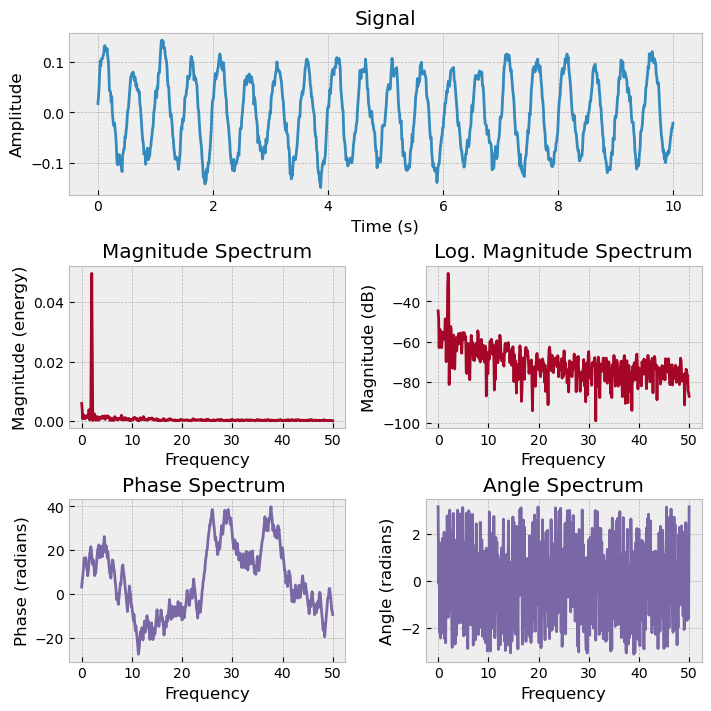

In [2]:
np.random.seed(0)

dt = 0.01    # sampling interval
Fs = 1 / dt  # sampling frequency
t = np.arange(0, 10, dt)

# generate noise:
nse = np.random.randn(len(t))
r = np.exp(-t / 0.05)
cnse = np.convolve(nse, r) * dt
cnse = cnse[:len(t)]

s = 0.1 * np.sin(4 * np.pi * t) + cnse  # the signal

fig = plt.figure(figsize=(7, 7), layout='constrained')
axs = fig.subplot_mosaic([["signal", "signal"],
                          ["magnitude", "log_magnitude"],
                          ["phase", "angle"]])
# plot time signal:
axs["signal"].set_title("Signal")
_ = axs["signal"].plot(t, s, color='C0')
axs["signal"].set_xlabel("Time (s)")
axs["signal"].set_ylabel("Amplitude")
# plot different spectrum types:
axs["magnitude"].set_title("Magnitude Spectrum")
_ = axs["magnitude"].magnitude_spectrum(s, Fs=Fs, color='C1')
axs["log_magnitude"].set_title("Log. Magnitude Spectrum")
_ = axs["log_magnitude"].magnitude_spectrum(s, Fs=Fs, scale='dB', color='C1')
axs["phase"].set_title("Phase Spectrum ")
_ = axs["phase"].phase_spectrum(s, Fs=Fs, color='C2')
axs["angle"].set_title("Angle Spectrum")
_ = axs["angle"].angle_spectrum(s, Fs=Fs, color='C2')

Let's see whether we can reproduce these results using *seisplot*.

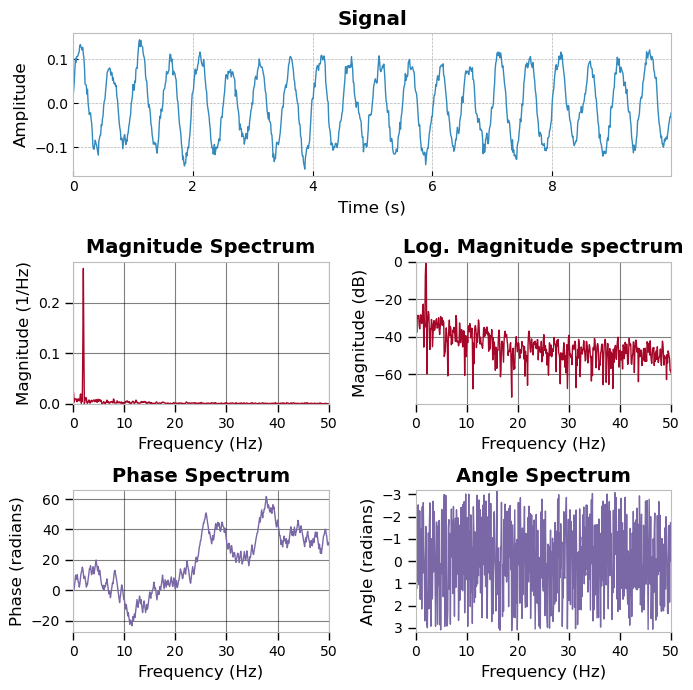

In [4]:
fig2 = plt.figure(figsize=(7, 7), layout='constrained')
axs2 = fig2.subplot_mosaic([["signal", "signal"],
                           ["magnitude", "log_magnitude"],
                           ["phase", "angle"]])
# plot time signal:
axs2["signal"].set_title("Signal", fontweight='bold')
_ = axs2["signal"].plot(t, s, color='C0', linewidth=1)
axs2["signal"].set_facecolor("white")
axs2["signal"].set_xlim(t[0], t[-1])
axs2["signal"].set_xlabel("Time (s)")
axs2["signal"].set_ylabel("Amplitude")
_, _ = seisplot.spectrum(s, vaxis=t, fig=fig2, ax=axs2["magnitude"],
                         amplitude=True, window=np.hamming,
                         linecolor="C1", title="Magnitude Spectrum",
                         hlabel="Frequency (Hz)", vlabel="Magnitude (1/Hz)",
                         hgrid="major", vgrid="major")
_, _ = seisplot.spectrum(s, vaxis=t, fig=fig2, ax=axs2["log_magnitude"],
                         amplitude=True, window=np.hamming,
                         scale="dB", linecolor="C1", title="Log. Magnitude spectrum",
                         hlabel="Frequency (Hz)", vlabel="Magnitude (dB)",
                         hgrid="major", vgrid="major")
_, _ = seisplot.spectrum(s, vaxis=t, fig=fig2, ax=axs2["phase"], unwrap=True,
                         phase=True, window=np.hamming,
                         linecolor="C2", title="Phase Spectrum",
                         hlabel="Frequency (Hz)", vlabel="Phase (radians)",
                         hgrid="major", vgrid="major")
_, _ = seisplot.spectrum(s, vaxis=t, fig=fig2, ax=axs2["angle"], unwrap=False,
                         phase=True, window=np.hamming,
                         linecolor="C2", title="Angle Spectrum",
                         hlabel="Frequency (Hz)", vlabel="Angle (radians)",
                         vmajorticks=1, vaxisbeg=-3.2, vaxisend=3.2)
plt.tight_layout()
plt.show()

Note that the magnitude spectrum in dB is normalized, i.e., the largest value is always 0. Also note that the `spectrum` method scales by the sampling interval in order to get results that are independent of the sampling rate. You get the same amplitude spectrum, independent of how the input data is sampled. The values therefore differ from Matplotlib's functions. In addition, the Matplotlib functions apply the Fourier transform normalization factor on the forward transform. This could also be done for the `spectrum` method when using the `fftnorm` option.

Now let's check whether the `spectrum` method gives a correct output amplitude using an analytical solution. The test is based on the famous Ricker wavelet which has an analytical solution for its amplitude spectrum. First, we create the signal:

In [5]:
def ricker(t,fm,t0):
    arg = np.pi**2 * fm**2 * (t-t0)**2
    return (1-2*arg)*np.exp(-arg)

dt = 0.001
t = np.arange(0, 1.0+dt/2, dt)
fm = 20
t0 = 0.2
s = ricker(t, fm, t0)

A Ricker wavelet is a zero-phase wavelet. Due to the time shift of `t0`, we should end up with a linear phase spectrum (see Fourier shifting theorem). The amplitude spectrum should have its peak at the main frequency `fm`. The maximum value of the amplitude spectrum at this frequency should be:

In [6]:
ampspec_max = 2.0 / (np.sqrt(np.pi) * fm * np.e)
print(ampspec_max)

0.020755374871029738


The phase spectrum (in rad) should be a linear function as follows:

In [7]:
fmax = 120
df = 1
freq = np.arange(0, fmax+df/2, df)
phase = -2 * np.pi * freq * t0

So, let's create the amplitude and phase spectrum, respectively. We restrict the frequency range for plotting to 120 Hz (alread set above as `fmax`). Above a certain frequency, we will run into numerical issues as the values of the complex spectrum become very small. This is to be expected.

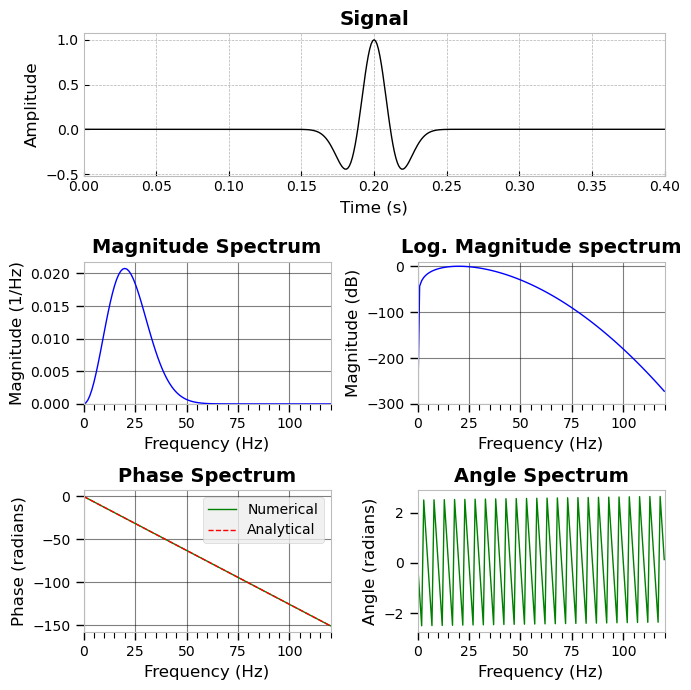

In [8]:
fig3 = plt.figure(figsize=(7, 7), layout='constrained')
axs3 = fig3.subplot_mosaic([["signal", "signal"],
                           ["magnitude", "log_magnitude"],
                           ["phase", "angle"]])
# plot time signal:
axs3["signal"].set_title("Signal", fontweight='bold')
_ = axs3["signal"].plot(t, s, color='black', linewidth=1)
axs3["signal"].set_facecolor("white")
axs3["signal"].set_xlim(0, 0.4)
axs3["signal"].set_xlabel("Time (s)")
axs3["signal"].set_ylabel("Amplitude")
_, _ = seisplot.spectrum(s, vaxis=t, fig=fig3, ax=axs3["magnitude"], amplitude=True, 
                         linecolor="blue", title="Magnitude Spectrum",
                         hlabel="Frequency (Hz)", vlabel="Magnitude (1/Hz)",
                         hminorticks=5, hgrid="major", vgrid="major", haxisend=fmax)
_, _ = seisplot.spectrum(s, vaxis=t, fig=fig3, ax=axs3["log_magnitude"], amplitude=True,
                         scale="dB", linecolor="blue", title="Log. Magnitude spectrum",
                         hlabel="Frequency (Hz)", vlabel="Magnitude (dB)", vaxisbeg=10,
                         vaxisend=-300, hminorticks=5, hgrid="major", vgrid="major", 
                         haxisend=fmax)
_, _ = seisplot.spectrum(s, vaxis=t, fig=fig3, ax=axs3["phase"], unwrap=True,
                         phase=True, linecolor="green", title="Phase Spectrum",
                         hlabel="Frequency (Hz)", vlabel="Phase (radians)",
                         hminorticks=5, hgrid="major", vgrid="major", haxisend=fmax,
                         label="Numerical")
_, _ = seisplot.spectrum(s, vaxis=t, fig=fig3, ax=axs3["angle"], unwrap=False,
                         phase=True, linecolor="green", title="Angle Spectrum",
                         hlabel="Frequency (Hz)", vlabel="Angle (radians)",
                         hminorticks=5, haxisend=fmax)
# plot expected linear phase on top
axs3["phase"].plot(freq, phase, color="red", linestyle="dashed", linewidth=1, label="Analytical")
axs3["phase"].legend()
plt.tight_layout()
plt.show()

The linear amplitude spectrum has the expected peak at 20 Hz with a value of 0.02076, i.e., the numerical implementation agrees with the analytical solution. The (unwrapped) phase spectrum is perfectly linear. The analytically calculated (i.e., expected) phase agrees perfectly with the numerically calculated phase. Obviously, when you plot the spectra up to the Nyquist frequency, then there will be deviations due to numerical issues. The complex values of the Fourier spectrum are tiny for larger frequencies, and calculating the phase or the log. magnitude spectrum, where divisions are involved, becomes somewhat unstable.